# 📊 Diff-Integrator Benchmark Visualization
This notebook visualizes the loss descent and structural changes from the 2KZV joint-refinement benchmark.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import py3Dmol

sns.set_theme(style="whitegrid")
from pathlib import Path

## 📉 Loss Curves
Let's load the `loss_history.npy` from our benchmark to see how the optimizer smoothly minimized the objective function.

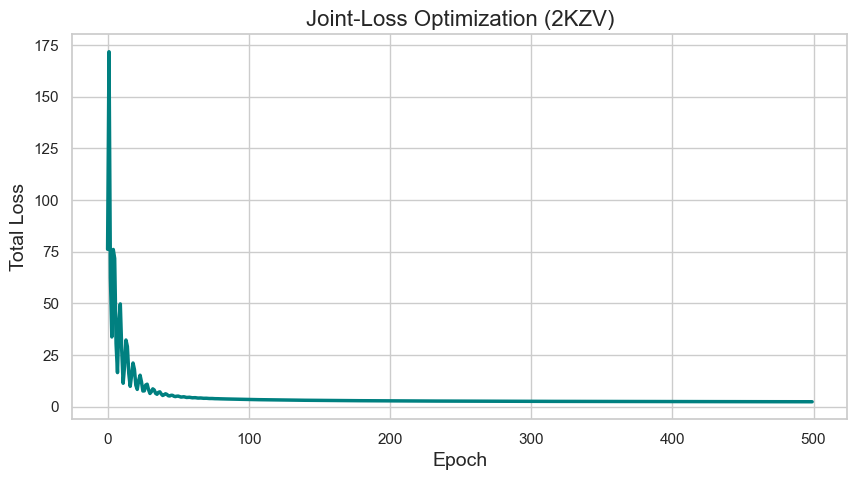

In [2]:
res_dir = Path("../benchmarks/results/2KZV")
history = np.load(res_dir / "loss_history.npy")

plt.figure(figsize=(10, 5))
plt.plot(history, color="teal", linewidth=2.5)
plt.title("Joint-Loss Optimization (2KZV)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Total Loss", fontsize=14)
plt.show()

## 🧬 Structural Drift
Using `py3Dmol`, we can superimpose the `initial.pdb` (native NMR fold) and the `final.pdb` (refined fold). We added a `GeometryLoss` to keep the structural drift under 2 Å while perfectly satisfying the chemical shifts and RDCs.

In [3]:
view = py3Dmol.view(width=800, height=500)

with open(res_dir / "initial.pdb") as f:
    view.addModel(f.read(), "pdb")
view.setStyle({"model": 0}, {"stick": {"color": "gray", "radius": 0.1}, "cartoon": {"color": "gray", "opacity": 0.5}})

with open(res_dir / "final.pdb") as f:
    view.addModel(f.read(), "pdb")
view.setStyle({"model": 1}, {"stick": {"color": "teal", "radius": 0.1}, "cartoon": {"color": "teal"}})

view.zoomTo()
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.